In [3]:
import os

import wfdb
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
plt.style.use("ggplot")

In [2]:
DATASET_PATH = "ptb-diagnostic-ecg-database-1.0.0"

In [5]:
patients = os.listdir(DATASET_PATH)

print(
    "Number of patients:",
    len(patients)
)

Number of patients: 290


In [7]:
records_per_patient = []

In [8]:
for patient in patients:

    patient_path = os.path.join(
        DATASET_PATH,
        patient
    )

    files = os.listdir(patient_path)

    hea_files = [

        f for f in files
        if f.endswith(".hea")
    ]

    records_per_patient.append(
        len(hea_files)
    )

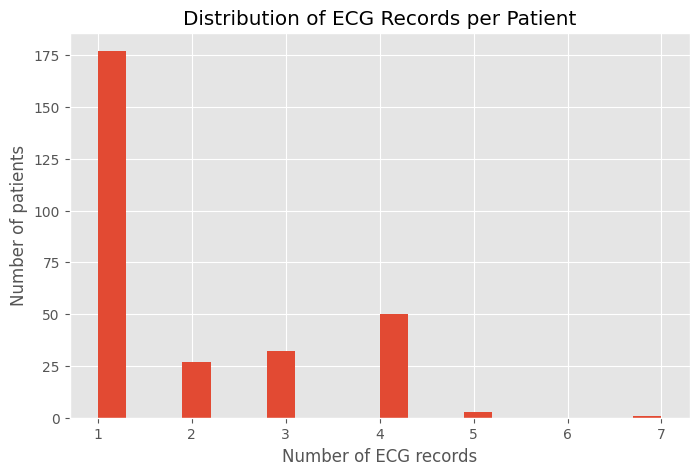

In [ ]:
# histogram
plt.figure(figsize=(8,5))

plt.hist(
    records_per_patient,
    bins=20
)

plt.title(
    "Distribution of ECG Records per Patient"
)

plt.xlabel(
    "Number of ECG records"
)

plt.ylabel(
    "Number of patients"
)

plt.show()

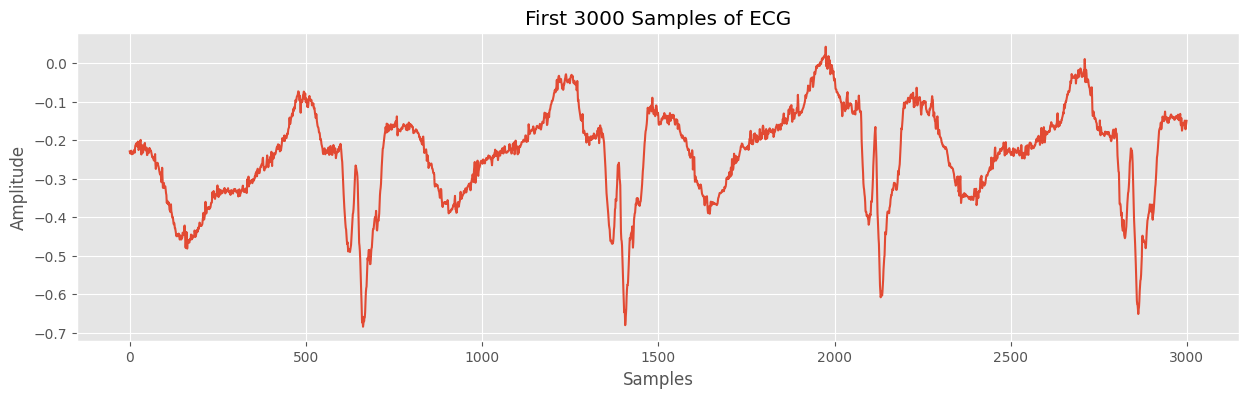

In [14]:
# Short ECG segment
plt.figure(figsize=(15,4))

plt.plot(
    signal[:3000]
)

plt.title(
    "First 3000 Samples of ECG"
)

plt.xlabel("Samples")

plt.ylabel("Amplitude")

plt.show()

In [16]:
lead_names = record.sig_name[:12]

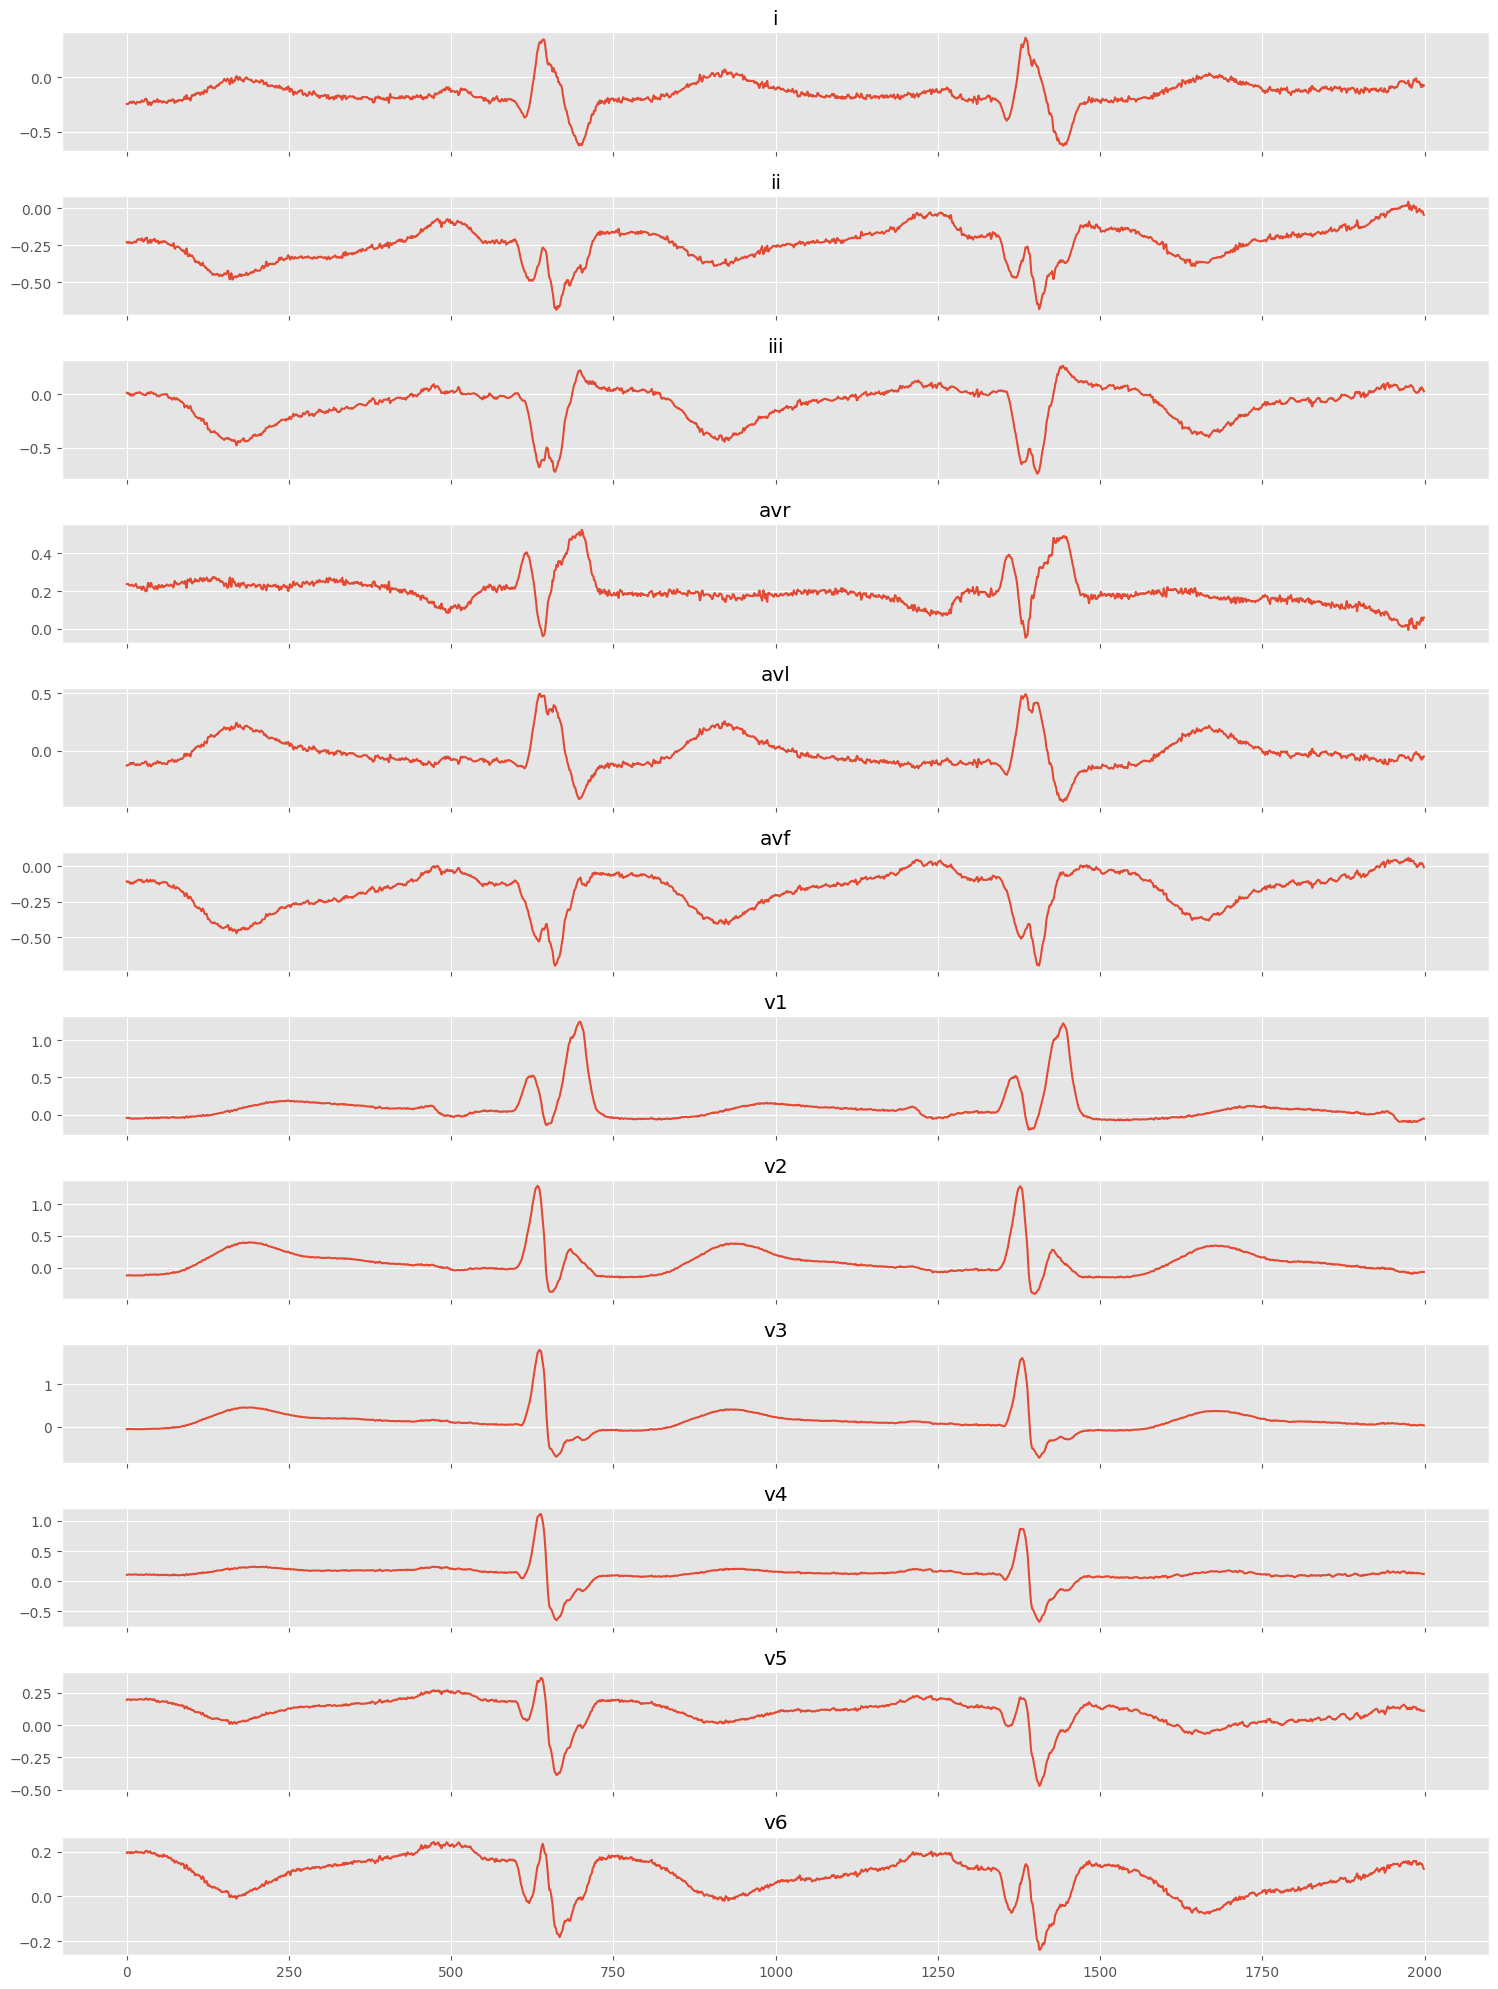

In [17]:
fig, axes = plt.subplots(
    12,
    1,
    figsize=(15,20),
    sharex=True
)

for i in range(12):

    axes[i].plot(
        record.p_signal[:2000, i]
    )

    axes[i].set_title(
        lead_names[i]
    )

plt.tight_layout()

plt.show()

In [18]:
all_comments = []

In [19]:
for patient in patients:

    patient_path = os.path.join(
        DATASET_PATH,
        patient
    )

    files = os.listdir(patient_path)

    hea_files = [

        f for f in files
        if f.endswith(".hea")
    ]

    for hea in hea_files:

        record_name = hea.replace(
            ".hea",
            ""
        )

        full_path = os.path.join(
            patient_path,
            record_name
        )

        try:

            record = wfdb.rdrecord(
                full_path
            )

            comments = " ".join(
                record.comments
            )

            all_comments.append(
                comments
            )

        except:
            pass

In [20]:
comments_df = pd.DataFrame({

    "comments": all_comments
})

In [21]:
keywords = [

    "anterior",
    "inferior",
    "lateral",
    "posterior"
]

counts = []

In [22]:
for key in keywords:

    count = comments_df[
        "comments"
    ].str.lower().str.contains(
        key
    ).sum()

    counts.append(count)

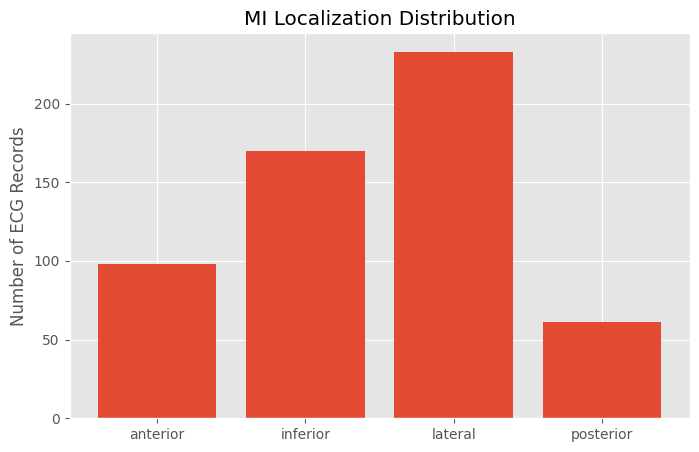

In [23]:
plt.figure(figsize=(8,5))

plt.bar(
    keywords,
    counts
)

plt.title(
    "MI Localization Distribution"
)

plt.ylabel(
    "Number of ECG Records"
)

plt.show()

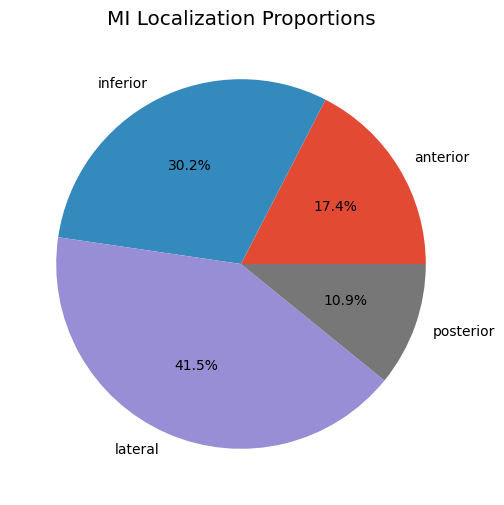

In [24]:
plt.figure(figsize=(6,6))

plt.pie(
    counts,
    labels=keywords,
    autopct='%1.1f%%'
)

plt.title(
    "MI Localization Proportions"
)

plt.show()

In [25]:
combo_list = []

In [26]:
for comment in comments_df["comments"]:

    text = comment.lower()

    labels = []

    if "anter" in text:
        labels.append("anterior")

    if "infer" in text:
        labels.append("inferior")

    if "later" in text:
        labels.append("lateral")

    if "poster" in text:
        labels.append("posterior")

    combo = "_".join(labels)

    combo_list.append(combo)

In [27]:
comments_df["combo"] = combo_list

In [28]:
combo_counts = comments_df[
    "combo"
].value_counts().head(10)

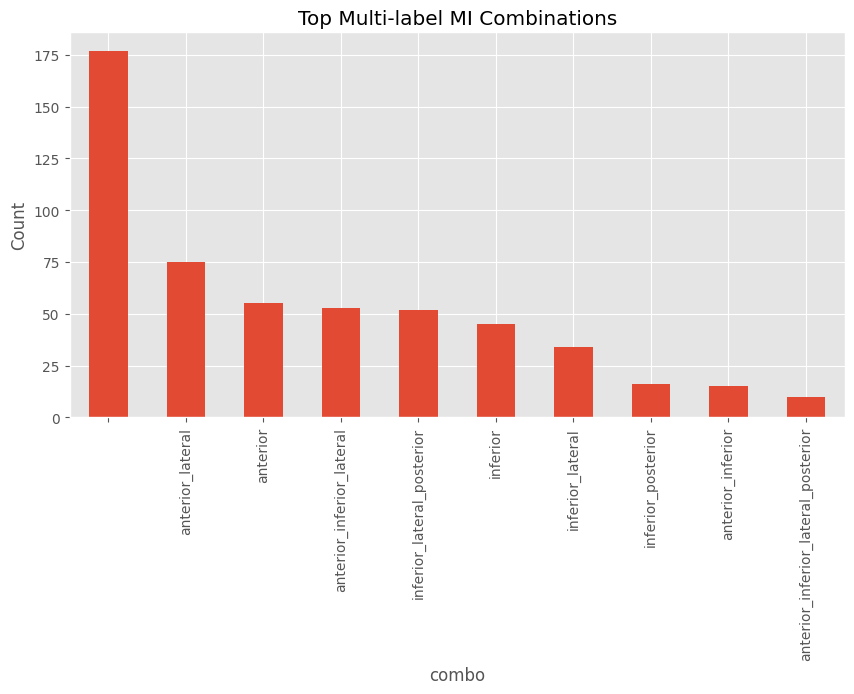

In [29]:
plt.figure(figsize=(10,5))

combo_counts.plot(
    kind="bar"
)

plt.title(
    "Top Multi-label MI Combinations"
)

plt.ylabel("Count")

plt.show()

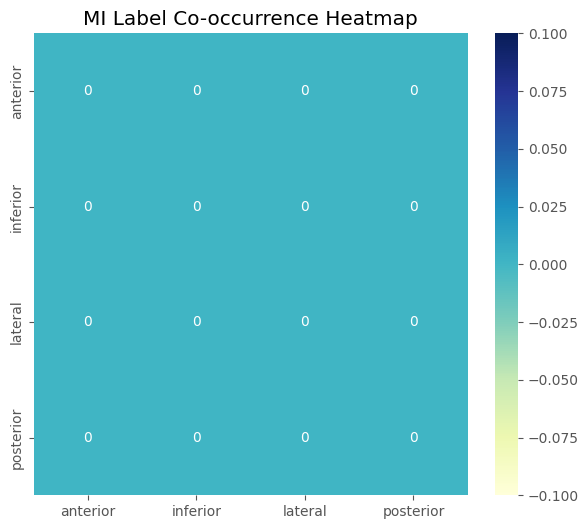

In [34]:
plt.figure(figsize=(7,6))

sns.heatmap(
    co_matrix,
    annot=True,
    cmap="YlGnBu"
)

plt.title(
    "MI Label Co-occurrence Heatmap"
)

plt.show()